**Problem Statement**

**Retail supermarket** chains operate across hundreds of stores and sell thousands of product families, each with distinct demand patterns driven by seasonality, promotions, holidays, wages cycles, and macroeconomic shocks (e.g., oil prices in an oil-dependent economy). Inaccurate sales forecasts lead to two costly outcomes: overstocking, which ties up capital and increases spoilage/waste for perishable goods, and stockouts, which cause lost sales and poor customer experience.

**Dataset**
The project contains multiple datasets such as historical sales, product information, store
information, holidays, transactions, external indicators, and a prediction dataset.

**Dataset Description**
In this competition, we will predict sales for the thousands of product families sold at
Favorita stores located in Ecuador. The training data includes dates, store and product
information, whether that item was being promoted, as well as the sales numbers. Additional
files include supplementary information that may be useful in building your models.

Corporación Favorita, a large Ecuadorian grocery retailer, needs a data-driven forecasting solution that predicts daily unit sales for each product family at each store, 15 days into the future. The historical data spans multiple stores, product families, and several years of daily transactions, and is influenced by irregular factors such as:

**Promotions** — items placed onpromotion show demand spikes that must be modeled explicitly.

**Holidays and transferred holidays** — a holiday's effective calendar impact may fall on a different date than its nominal date, and this mapping must be resolved correctly.
Payday effects — public-sector wages paid on the 15th and last day of each month create recurring demand surges.

**External shocks** — the April 2016 earthquake caused a temporary, abnormal spike in essential-goods sales that a naive model would misinterpret as part of a normal seasonal pattern.

**Oil price fluctuations** — as a proxy for macroeconomic health in an oil-dependent country, oil prices may correlate with broader consumer spending behavior.

**The core problem:** Build and evaluate machine learning and time-series forecasting models that accurately predict sales for each (date, store, product family) combination in the 15-day test horizon, while accounting for promotions, holiday effects, payday cycles, and known anomalies — and present the results through an interactive dashboard that supports inventory planning and supply chain decisions.

**Objective:** Minimize forecast error (e.g., RMSLE, since sales values span several orders of magnitude and fractional units) across thousands of store-product series simultaneously, while generating actionable business insights on demand drivers (promotions, seasonality, holidays, and external shocks) that inventory planners can use to reduce stockouts and overstocking

**Step1:-import neccessary libraries**

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


Data Loading and Basic Exploratory Data Analysis (EDA)

In [2]:
train_raw = pd.read_csv('../data/train.csv', parse_dates=['date'])
test_raw  = pd.read_csv('../data/test.csv', parse_dates=['date'])
stores    = pd.read_csv('../data/stores.csv').rename(columns={'type': 'store_type'})
oil_raw   = pd.read_csv('../data/oil.csv', parse_dates=['date'])
holidays  = pd.read_csv('../data/holidays_events.csv', parse_dates=['date'])

1.1 Daily Total Sales Trend

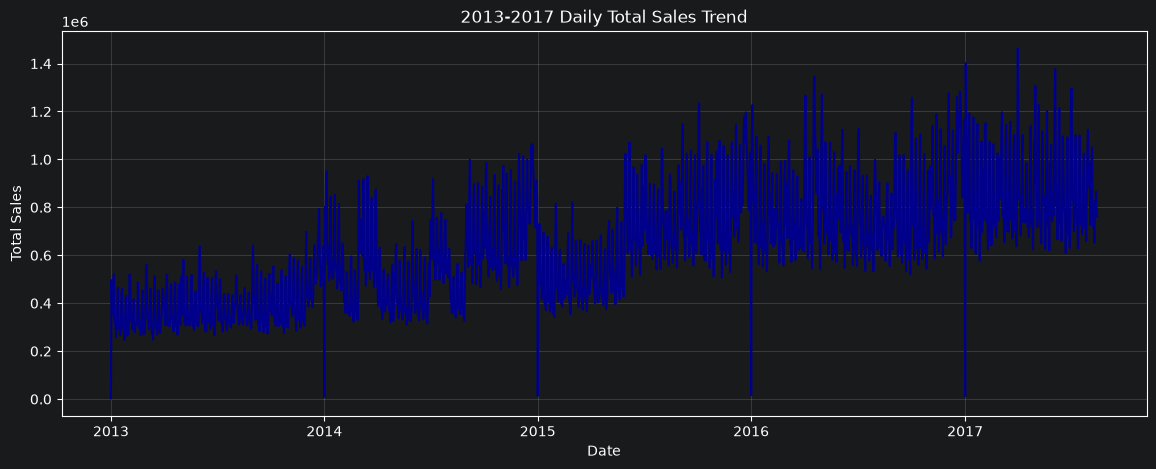

In [3]:
# Calculate total daily sales
daily_sales = train_raw.groupby('date')['sales'].sum().reset_index()

# Plot the daily sales trend
plt.figure(figsize=(14,5))
plt.plot(daily_sales['date'], daily_sales['sales'], color='darkblue')

# Chart title and labels
plt.title('2013-2017 Daily Total Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')

# Add grid
plt.grid(alpha=0.3)

# Display the plot
plt.show()

1.2 Holiday vs Non-Holiday Sales Comparison (Illustrative Only – Exact Matching Will Be Done Later)

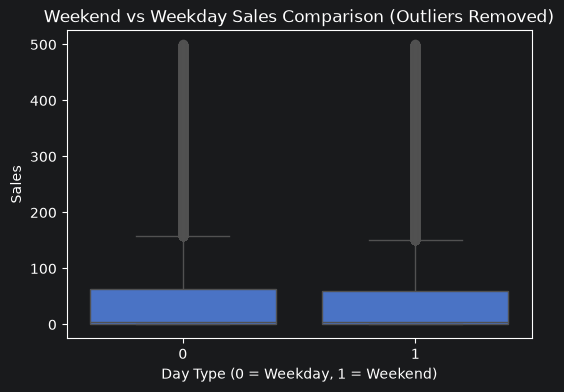

In [4]:
# Create a weekend indicator (1 = Weekend, 0 = Weekday)
train_raw['is_weekend'] = (train_raw['date'].dt.dayofweek >= 5).astype(int)

# Create the box plot
plt.figure(figsize=(6,4))
sns.boxplot(
    x='is_weekend',
    y='sales',
    data=train_raw[train_raw['sales'] < 500]  # Exclude extreme outliers for better visualization
)

# Add title and axis labels
plt.title('Weekend vs Weekday Sales Comparison (Outliers Removed)')
plt.xlabel('Day Type (0 = Weekday, 1 = Weekend)')
plt.ylabel('Sales')

# Display the plot
plt.show()

1.3 Relationship Between Oil Prices and Sales

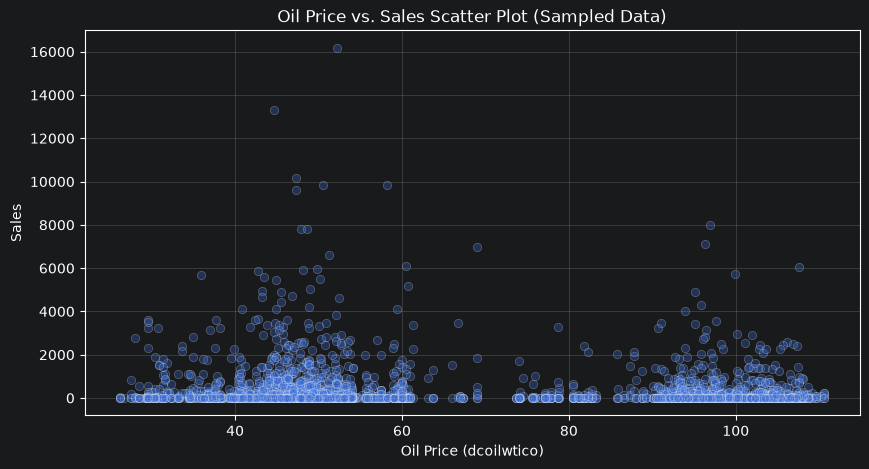

In [5]:
# Resample oil price data to daily frequency
oil_daily = oil_raw.set_index('date').resample('D').mean().reset_index()

# Merge sales data with daily oil prices
merged_oil = train_raw.merge(oil_daily, on='date', how='left')

# Create a scatter plot using a sample of 5,000 records
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='dcoilwtico',
    y='sales',
    data=merged_oil.sample(5000),
    alpha=0.3
)

# Add title and axis labels
plt.title('Oil Price vs. Sales Scatter Plot (Sampled Data)')
plt.xlabel('Oil Price (dcoilwtico)')
plt.ylabel('Sales')

# Add grid
plt.grid(alpha=0.3)

# Display the plot
plt.show()

Cell 3: Feature Engineering (Based on the Original Approach, with Minor Adjustments to Support the Validation Set)

In [6]:
print("Starting Feature Engineering...")

Starting Feature Engineering...


3.1 Data Filtering: Use Data from April 1, 2017 Onward

In [7]:
# Keep only records from April 1, 2017 onward for training
train = train_raw[train_raw['date'] >= '2017-04-01'].reset_index(drop=True)

# Create a copy of the test dataset
test = test_raw.copy()

3.2 Dead Product Identification (90 Consecutive Days of Zero Sales)

products that have had absolutely no sales for the last 90 consecutive days.

In [8]:
# Select data from the last 90 days
last_90_days = train[train['date'] >= '2017-05-16']

# Calculate the total sales for each store-product family combination
inactive_stats = last_90_days.groupby(['store_nbr', 'family'])['sales'].sum().reset_index()

# Identify combinations with zero total sales over the last 90 days
true_dead_keys = set(zip(
    inactive_stats[inactive_stats['sales'] == 0]['store_nbr'],
    inactive_stats[inactive_stats['sales'] == 0]['family']
))

# Display the number of inactive combinations
print(f"Identified {len(true_dead_keys)} store-family combinations with zero sales for 90 consecutive days.")

Identified 82 store-family combinations with zero sales for 90 consecutive days.


**Oil price and check external features**

In [9]:
oil = oil_raw.set_index('date').resample('D').mean().interpolate(limit_direction='both').reset_index()
#interpolate missing values,using the nearby values
#.reset_index() convert the data back into normal column
#step2:- create "oil price feature"
#7-days caluclate rolling average oil price
#this will helps the model to understand the overall oil price trend
oil['oil_roll_7'] = oil['dcoilwtico'].rolling(7,min_periods=1).mean()   # real 7-day rolling mean (past + today)
oil['oil_lag_1'] = oil['dcoilwtico'].shift(1).ffill().bfill()            # oil price 1 day AGO (past only, no leakage)
oil['oil_lag_3'] = oil['dcoilwtico'].shift(3).ffill().bfill()           # oil price 3 days AGO (past only, no leakage)

#step 3:- merge external features
def merge_base(df):
  df = df.merge(stores,on='store_nbr',how = 'left')
  df = df.merge(oil,on = 'date',how = 'left')
  return df
train = merge_base(train)
test = merge_base(test)

In [10]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,is_weekend,city,state,store_type,cluster,dcoilwtico,oil_roll_7,oil_lag_1,oil_lag_3
0,2756754,2017-04-01,1,AUTOMOTIVE,9.0,0,1,Quito,Pichincha,D,13,50.443333,49.035238,50.54,49.47
1,2756755,2017-04-01,1,BABY CARE,0.0,0,1,Quito,Pichincha,D,13,50.443333,49.035238,50.54,49.47
2,2756756,2017-04-01,1,BEAUTY,1.0,0,1,Quito,Pichincha,D,13,50.443333,49.035238,50.54,49.47
3,2756757,2017-04-01,1,BEVERAGES,3229.0,8,1,Quito,Pichincha,D,13,50.443333,49.035238,50.54,49.47
4,2756758,2017-04-01,1,BOOKS,0.0,0,1,Quito,Pichincha,D,13,50.443333,49.035238,50.54,49.47


In [11]:
#The oil columns (dcoilwtico, oil_roll_7, oil_lag_1, oil_lag_3) are the same for every family because oil is one price per day for the whole country. In the feature-engineering step you merge it onto the sales table using only the date:
d = train[train['date'] == '2017-05-10']
print(len(d))   # should be 1782 (54 stores x 33 families)
print(d[['dcoilwtico','oil_roll_7','oil_lag_1','oil_lag_3']].nunique())
print(d.groupby('store_nbr')[['city','cluster']].nunique().max())

1782
dcoilwtico    1
oil_roll_7    1
oil_lag_1     1
oil_lag_3     1
dtype: int64
city       1
cluster    1
dtype: int64


In [12]:
holidays.head()

#remove transferred holidays
#we only keep holidays that are actually observed on their original data
#holiday that are moved to another date can be excluded
holidays = holidays[holidays['transferred']==False]
holidays

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
...,...,...,...,...,...,...
345,2017-12-22,Additional,National,Ecuador,Navidad-3,False
346,2017-12-23,Additional,National,Ecuador,Navidad-2,False
347,2017-12-24,Additional,National,Ecuador,Navidad-1,False
348,2017-12-25,Holiday,National,Ecuador,Navidad,False


In [13]:
#create a function for the holiday indicator
# 'Work Day' rows are days people work INSTEAD of a holiday, so they must never be flagged as holidays.
# (Original code compared with 'work day' in lower case, which never matched the data's 'Work Day'.)
holidays_obs = holidays[holidays['type'] != 'Work Day']

def apply_holiday(df):
  df['is_holiday']=0
  for _,h in holidays_obs.iterrows():
    if h['locale']=='National':
      df.loc[df['date']==h['date'],'is_holiday']=1
    elif h['locale']=='Regional':
      df.loc[(df['date']==h['date']) &(df['state']==h['locale_name']),'is_holiday']=1
    elif h['locale']=='Local':
      df.loc[(df['date']==h['date']) &(df['city']==h['locale_name']),'is_holiday']=1
  return df

#apply the function on train and test data
train = apply_holiday(train)
test = apply_holiday(test)

**3.5 Time-based(temporal) feature engineering**

In [14]:
#create use full features from "date"  column
#features created
#1.day --> day of the month,
#day of week
#is_weekend
#is_payday (public-sector wages are paid on the 15th and on the last day of the month)


def create_temporal_features(df):
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['isweekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_weekend'] = df['isweekend']      # built for train AND test (it used to exist only on train_raw -> NaN in test)
    df['is_payday'] = ((df['day'] == 15) | (df['date'].dt.is_month_end)).astype(int)
    return df

train = create_temporal_features(train)
test = create_temporal_features(test)

In [15]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,is_weekend,city,state,store_type,cluster,dcoilwtico,oil_roll_7,oil_lag_1,oil_lag_3,is_holiday,day,dayofweek,isweekend,is_payday
0,2756754,2017-04-01,1,AUTOMOTIVE,9.0,0,1,Quito,Pichincha,D,13,50.443333,49.035238,50.54,49.47,0,1,5,1,0
1,2756755,2017-04-01,1,BABY CARE,0.0,0,1,Quito,Pichincha,D,13,50.443333,49.035238,50.54,49.47,0,1,5,1,0
2,2756756,2017-04-01,1,BEAUTY,1.0,0,1,Quito,Pichincha,D,13,50.443333,49.035238,50.54,49.47,0,1,5,1,0
3,2756757,2017-04-01,1,BEVERAGES,3229.0,8,1,Quito,Pichincha,D,13,50.443333,49.035238,50.54,49.47,0,1,5,1,0
4,2756758,2017-04-01,1,BOOKS,0.0,0,1,Quito,Pichincha,D,13,50.443333,49.035238,50.54,49.47,0,1,5,1,0


**3.6 combine train and test datasets create lag and rolling features**

In [16]:
df_all = pd.concat([train,test],ignore_index=True)
#sales from 21 days (3 weeks ago) --> lag features
df_all['sales_lag_21'] = df_all.groupby(['store_nbr','family'])['sales'].shift(21)
#sales from 28days means 4 weeks ago
#this will capture monthly and weekly recurring patterns
df_all['sales_lag_28'] = df_all.groupby(['store_nbr','family'])['sales'].shift(28)
#calculate the 7-days rolling average based on 21 days lagfeature
df_all['sales_roll_21_7'] = df_all.groupby(['store_nbr','family'])['sales_lag_21'].transform(
    lambda x:x.rolling(7,min_periods=1).mean()
)
#calculate the 3-days rolling average
df_all['promo_roll_3'] = df_all.groupby(['store_nbr','family'])['onpromotion'].transform(
    lambda x:x.rolling(3,min_periods=1).mean()
)
#combine dataset back into training and testing

train = df_all[df_all['date']<'2017-08-16'].dropna(subset=['sales_lag_28']).copy()
#test set starts from agust 16,2017
test = df_all[df_all['date']>='2017-08-16'].copy()

**3.7 encode the categorical features**

In [17]:
train.head()

,id,date,store_nbr,family,sales,onpromotion,is_weekend,city,state,store_type,...,oil_lag_3,is_holiday,day,dayofweek,isweekend,is_payday,sales_lag_21,sales_lag_28,sales_roll_21_7,promo_roll_3
49896,2806650,2017-04-29,1,AUTOMOTIVE,2.0,0,1,Quito,Pichincha,D,...,49.22,0,29,5,1,0,8.0,9.0,7.142857,0.0
49897,2806651,2017-04-29,1,BABY CARE,0.0,0,1,Quito,Pichincha,D,...,49.22,0,29,5,1,0,0.0,0.0,0.000000,0.0
49898,2806652,2017-04-29,1,BEAUTY,5.0,0,1,Quito,Pichincha,D,...,49.22,0,29,5,1,0,2.0,1.0,2.428571,0.0
49899,2806653,2017-04-29,1,BEVERAGES,2156.0,33,1,Quito,Pichincha,D,...,49.22,0,29,5,1,0,2729.0,3229.0,2237.571429,31.0
49900,2806654,2017-04-29,1,BOOKS,0.0,0,1,Quito,Pichincha,D,...,49.22,0,29,5,1,0,0.0,0.0,0.571429,0.0


In [18]:
#list the categorical column
cats = ['family','city','state','store_type']
encoders = {}
for col in cats:
  le = LabelEncoder()
  #fit the encoders on tarin and test data
  #This ensures that no unseen categories appears in the test set
  all_vals = pd.concat([train[col],test[col]],axis=0).fillna("unknown")
  le.fit(all_vals)
  train[col]=le.transform(train[col])
  test[col]=le.transform(test[col])
  encoders[col] = le

# Dead store-family keys were created with family NAMES (before encoding). Convert them to the encoded family
# codes so the dead-product rule and heatmap can actually match the encoded test data.
fam_to_code = {name: code for code, name in enumerate(encoders['family'].classes_)}
true_dead_keys_enc = {(s, fam_to_code[f]) for s, f in true_dead_keys if f in fam_to_code}
print(f"Dead keys (encoded): {len(true_dead_keys_enc)} of {len(true_dead_keys)}")

Dead keys (encoded): 82 of 82


In [19]:
train.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion',
       'is_weekend', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico',
       'oil_roll_7', 'oil_lag_1', 'oil_lag_3', 'is_holiday', 'day',
       'dayofweek', 'isweekend', 'is_payday', 'sales_lag_21', 'sales_lag_28',
       'sales_roll_21_7', 'promo_roll_3'],
      dtype='str')

In [20]:
features = ['store_nbr', 'family', 'onpromotion','is_weekend', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico',
            'oil_roll_7', 'oil_lag_1', 'oil_lag_3', 'is_holiday','day', 'dayofweek', 'isweekend', 'is_payday', 'sales_lag_21',
            'sales_lag_28', 'sales_roll_21_7', 'promo_roll_3']
cat_idx = ['family','city','state','store_type','cluster','store_nbr']

X_all = train[features]
y_all = np.log1p(train['sales'])

In [21]:
y_all

49896     1.098612
49897     0.000000
49898     1.791759
49899     7.676474
49900     0.000000
            ...   
244129    6.084802
244130    5.046987
244131    7.791824
244132    4.804021
244133    2.833213
Name: sales, Length: 194238, dtype: float64

**3.9 split the data**

In [22]:
#for timeseries data we should not use random splitting of the data beacuse it can randomly choose past and the current data
#In the time series the data can be splitting in chronologically because avoid data leakage
#exam :- tarin data --> jan 2013 ---> july 31-2017
# test data :- july 31 2017 to aug 1-15,2017
#the model learns from the past data and evaluates from the future data
#so it prevents data lekage, some of the data picking randomly random date in test validation influence the training data
split_date = '2017-07-31'
#create mask data from train data
train_mask = train['date']<=split_date
val_mask = (train['date']>split_date) & (train['date']<'2017-08-16')

X_train = X_all[train_mask]
y_train = y_all[train_mask]
X_val = X_all[val_mask]
y_val = y_all[val_mask]
#display the size of training and validation data
print(f"train set size: {len(X_train)}, Validation set size: {len(X_val)}")

#training data = 167508    , test = 26730

train set size: 167508, Validation set size: 26730


4.1 LightGBM

In [23]:
import sys

print(sys.executable)
print(sys.version)

import sklearn
print("scikit-learn:", sklearn.__version__)

import lightgbm
print("LightGBM:", lightgbm.__version__)

/Users/shivakumargl/PycharmProjects/Retail-Sales-Forecasting/.venv/bin/python
3.11.13 (main, Jun  3 2025, 18:38:25) [Clang 17.0.0 (clang-1700.3.19.1)]
scikit-learn: 1.9.1
LightGBM: 4.7.0


In [24]:
import sklearn
import lightgbm
from lightgbm.compat import SKLEARN_INSTALLED

print("Python:", __import__("sys").version)
print("sklearn:", sklearn.__version__)
print("LightGBM:", lightgbm.__version__)
print("LightGBM sees sklearn:", SKLEARN_INSTALLED)
print("sklearn location:", sklearn.__file__)

Python: 3.11.13 (main, Jun  3 2025, 18:38:25) [Clang 17.0.0 (clang-1700.3.19.1)]
sklearn: 1.9.1
LightGBM: 4.7.0
LightGBM sees sklearn: True
sklearn location: /Users/shivakumargl/PycharmProjects/Retail-Sales-Forecasting/.venv/lib/python3.11/site-packages/sklearn/__init__.py


In [25]:
import sys
print(sys.version)
print(sys.executable)

3.11.13 (main, Jun  3 2025, 18:38:25) [Clang 17.0.0 (clang-1700.3.19.1)]
/Users/shivakumargl/PycharmProjects/Retail-Sales-Forecasting/.venv/bin/python


In [26]:
import lightgbm as lgb

# Initialize model
m_lgb = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=63,
    random_state=42,
    n_jobs=-1
)

# Fit model
m_lgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=0)
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1812
[LightGBM] [Info] Number of data points in the train set: 167508, number of used features: 21
[LightGBM] [Info] Start training from score 3.630703
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[645]	training's l2: 0.162063	valid_1's l2: 0.184512


,num_leaves,63
,learning_rate,0.01
,n_estimators,1000
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


4.2 XGBOOST

In [27]:
import xgboost as xgb
#create copies of training and validation and test features
#use the copy() so the original data remainsunchanghed
X_tr_x = X_train.copy()
X_val_x = X_val.copy()
X_te_x = test[features].copy()

# Convert categorical columns to int, then to 'category' with the SAME category list in train/val/test
# (so XGBoost maps every category code identically at training and prediction time).
for c in cat_idx:
    all_cats = sorted(set(X_tr_x[c].astype(int)) | set(X_val_x[c].astype(int)) | set(X_te_x[c].astype(int)))
    cat_type = pd.CategoricalDtype(categories=all_cats)
    X_tr_x[c]  = X_tr_x[c].astype(int).astype(cat_type)
    X_val_x[c] = X_val_x[c].astype(int).astype(cat_type)
    X_te_x[c]  = X_te_x[c].astype(int).astype(cat_type)

#apply the xgboost
m_xgb=xgb.XGBRegressor(
    n_estimators=800,learning_rate=0.04,max_depth=7,
    tree_method='hist',enable_categorical=True,
    random_state=42,n_jobs=-1
)

#fit the model
m_xgb.fit(
    X_tr_x,y_train,
    eval_set=[(X_val_x,y_val)],
    verbose = False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


5.Validation prediction and ensemble weight search

In [28]:
p_lgb_val = np.expm1(m_lgb.predict(X_val))
#np.expm1() : converts logscale predicition in to original values (np.log1p(train['sales]))
p_xgb_val = np.expm1(m_xgb.predict(X_val_x))

#find the error
def rmsle(y_true,y_pred):
  return np.sqrt(np.mean((np.log1p(y_true)-np.log1p(y_pred))**2))

#y_val is on the log1p scale, predictions are on the original scale -> bring y_val back to the original scale
y_val_true = np.expm1(y_val)

#grid search for the best ensemble weights
best_score = 1e9     # this is scientific notation  1e9 = 1 * 10^9
best_w = None

for w1 in np.arange(0.1,0.7,0.05):
  w2 = 1 - w1
  #weighted ensemble prediction
  pred = (
      w1 * p_lgb_val +
      w2 * p_xgb_val
  )
 #calculate rmsle
  score = rmsle(y_val_true,pred)

 #update the best weights if the score improves
  if score < best_score:
    best_score = score
    best_w = [w1,w2]
print(
    f"best ensemble weights: "
    f"LightGBM={best_w[0]:.2f},"
    f"Xgboost={best_w[1]:.2f},"
    f"RMSLE={best_score:.4f}"
)

# --- FIX START ---
# Create a temporary DataFrame for LightGBM prediction, ensuring categorical features are integer type
X_te_lgb_for_predict = X_te_x.copy()
for c in cat_idx:
    if c in X_te_lgb_for_predict.columns:
        # Convert back to integer type, consistent with X_train when m_lgb was fitted
        X_te_lgb_for_predict[c] = X_te_lgb_for_predict[c].astype(int)

#generate the ensemble prediction on test dataset
p_lgb_test = np.expm1(m_lgb.predict(X_te_lgb_for_predict)) # Use the adjusted DataFrame for LightGBM
p_xgb_test = np.expm1(m_xgb.predict(X_te_x)) # Calculate p_xgb_test for the test dataset


#compute the final ensemble predicitons

test['sales'] = (
    best_w[0]*p_lgb_test + best_w[1]*p_xgb_test
)

#ensure that sales prediciton are non- negative
test['sales'] = np.clip(test['sales'],0,None)

best ensemble weights: LightGBM=0.25,Xgboost=0.75,RMSLE=0.4156


In [29]:
test['sales']

244134       4.460918
244135       0.059807
244136       5.001966
244137    2443.263515
244138       0.226791
             ...     
272641     342.052512
272642      98.383993
272643    1157.566720
272644      50.894465
272645      11.670284
Name: sales, Length: 28512, dtype: float64

In [30]:
X_val

,store_nbr,family,onpromotion,is_weekend,city,state,store_type,cluster,dcoilwtico,oil_roll_7,...,oil_lag_3,is_holiday,day,dayofweek,isweekend,is_payday,sales_lag_21,sales_lag_28,sales_roll_21_7,promo_roll_3
217404,1,0,0,0,18,12,3,13,49.19,49.525714,...,49.883333,0,1,1,0,0,7.000,5.000,4.000000,0.000000
217405,1,1,0,0,18,12,3,13,49.19,49.525714,...,49.883333,0,1,1,0,0,0.000,0.000,0.000000,0.000000
217406,1,2,0,0,18,12,3,13,49.19,49.525714,...,49.883333,0,1,1,0,0,4.000,6.000,2.857143,0.000000
217407,1,3,26,0,18,12,3,13,49.19,49.525714,...,49.883333,0,1,1,0,0,2372.000,2284.000,2255.857143,22.000000
217408,1,4,0,0,18,12,3,13,49.19,49.525714,...,49.883333,0,1,1,0,0,1.000,0.000,0.285714,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244129,9,28,0,0,18,12,1,6,47.57,48.357143,...,48.403333,0,15,1,0,1,320.009,320.401,392.798569,0.000000
244130,9,29,1,0,18,12,1,6,47.57,48.357143,...,48.403333,0,15,1,0,1,51.879,118.927,86.165143,0.666667
244131,9,30,148,0,18,12,1,6,47.57,48.357143,...,48.403333,0,15,1,0,1,2100.046,2178.149,1565.428143,54.000000
244132,9,31,8,0,18,12,1,6,47.57,48.357143,...,48.403333,0,15,1,0,1,5.000,0.000,1.857143,9.000000


In [31]:
# 1. Re-check the ensemble weights on the correct (original) scale
y_val_true = np.expm1(y_val)

def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))

best_score = 1e9
best_w = None

for w1 in np.arange(0.1, 0.7, 0.05):
    w2 = 1 - w1
    pred = w1 * p_lgb_val + w2 * p_xgb_val
    score = rmsle(y_val_true, pred)
    if score < best_score:
        best_score = score
        best_w = [w1, w2]

print(f"Corrected Validation RMSLE: {best_score:.4f} (LGBM: {best_w[0]:.2f}, XGB: {best_w[1]:.2f})")

# 2. Rebuild test predictions with the FINAL weights so the submission, metrics and saved weights all agree
test['sales'] = np.clip(best_w[0]*p_lgb_test + best_w[1]*p_xgb_test, 0, None)
print("Test predictions rebuilt with final weights. The submission file is written in step 7 (after post-processing).")

Corrected Validation RMSLE: 0.4156 (LGBM: 0.25, XGB: 0.75)
Test predictions rebuilt with final weights. The submission file is written in step 7 (after post-processing).


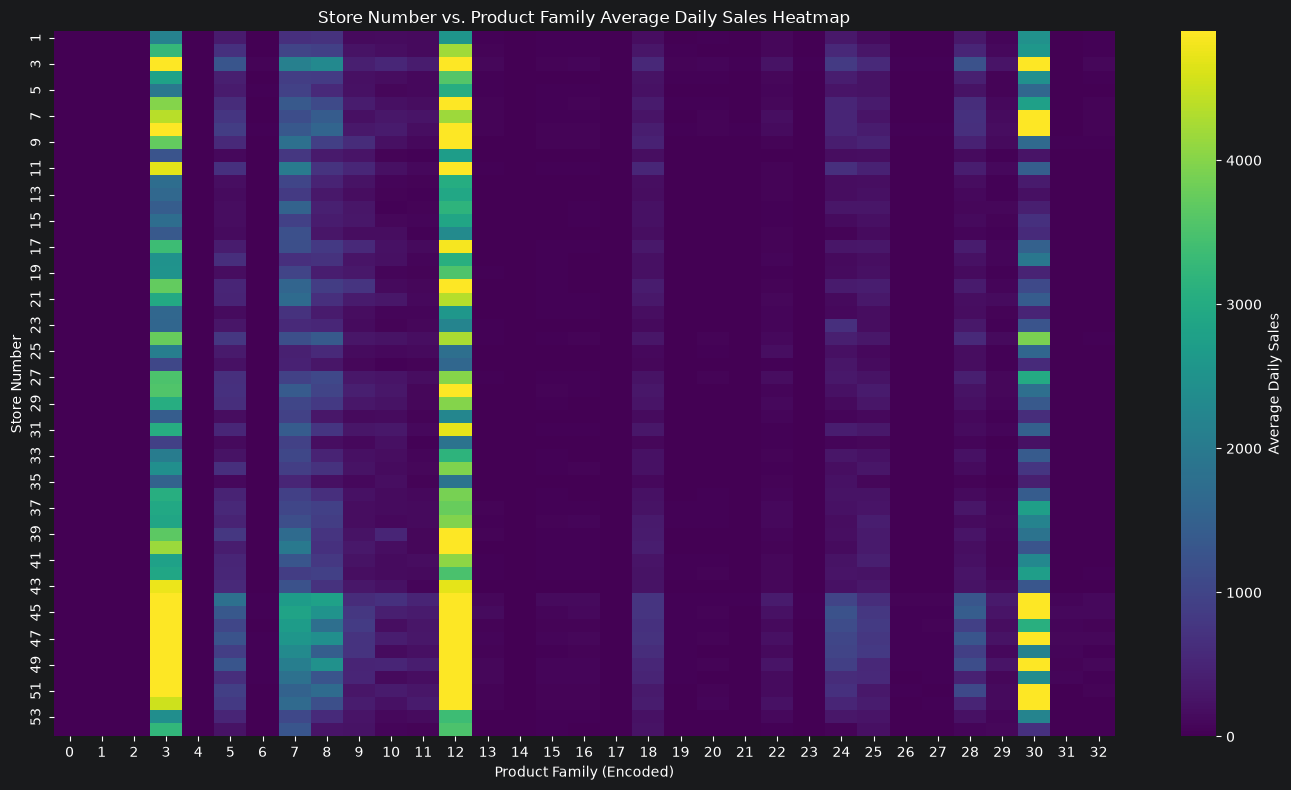

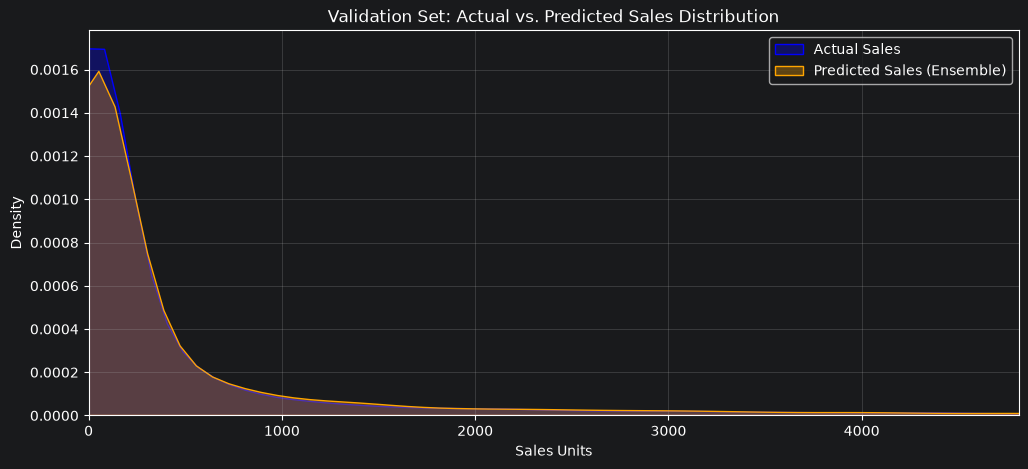

In [32]:
# 6.1 Matrix of Store vs. Product Family Sales Dynamics
pivot_sales = train.groupby(['store_nbr', 'family'])['sales'].mean().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_sales,
    cmap='viridis',
    robust=True,
    cbar_kws={'label': 'Average Daily Sales'}
)
plt.title('Store Number vs. Product Family Average Daily Sales Heatmap')
plt.xlabel('Product Family (Encoded)')
plt.ylabel('Store Number')
plt.tight_layout()
plt.show()


# 6.2 Actual vs. Predicted Sales Distribution on Validation Set
final_val_pred = best_w[0] * p_lgb_val + best_w[1] * p_xgb_val

plt.figure(figsize=(12, 5))
sns.kdeplot(
    y_val_true,
    label='Actual Sales',
    color='blue',
    fill=True,
    alpha=0.3
)
sns.kdeplot(
    final_val_pred,
    label='Predicted Sales (Ensemble)',
    color='orange',
    fill=True,
    alpha=0.3
)
plt.title('Validation Set: Actual vs. Predicted Sales Distribution')
plt.xlabel('Sales Units')
plt.ylabel('Density')
plt.xlim(0, np.percentile(y_val_true, 98))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

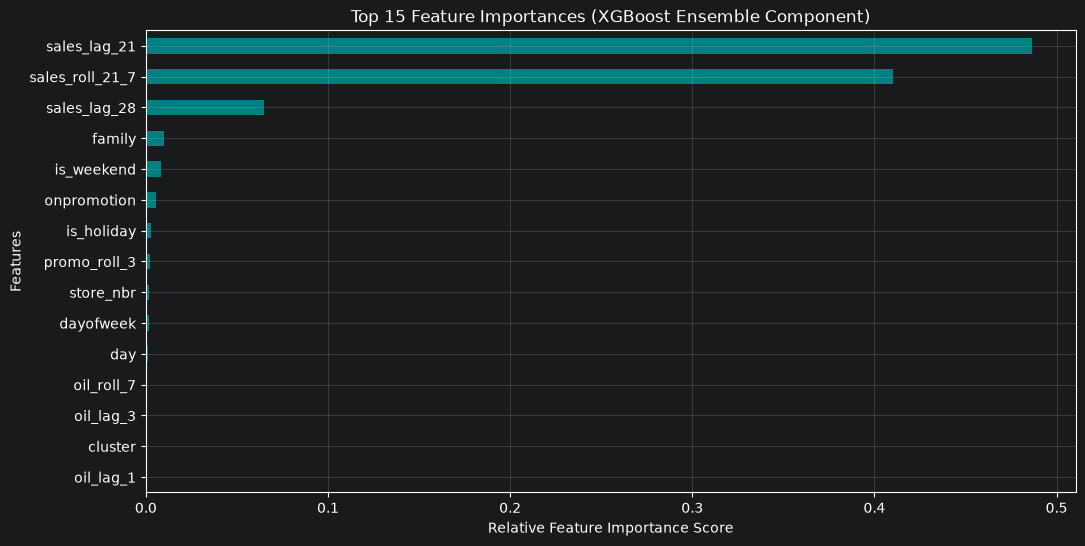

In [33]:
# 7. Feature Importance Analysis
plt.figure(figsize=(12, 6))
xgb_importance = pd.Series(m_xgb.feature_importances_, index=features).sort_values(ascending=True)
xgb_importance.tail(15).plot(kind='barh', color='teal')

plt.title('Top 15 Feature Importances (XGBoost Ensemble Component)')
plt.xlabel('Relative Feature Importance Score')
plt.ylabel('Features')
plt.grid(alpha=0.3)
plt.show()

**6.Visualization diognastics**


* check combination of features




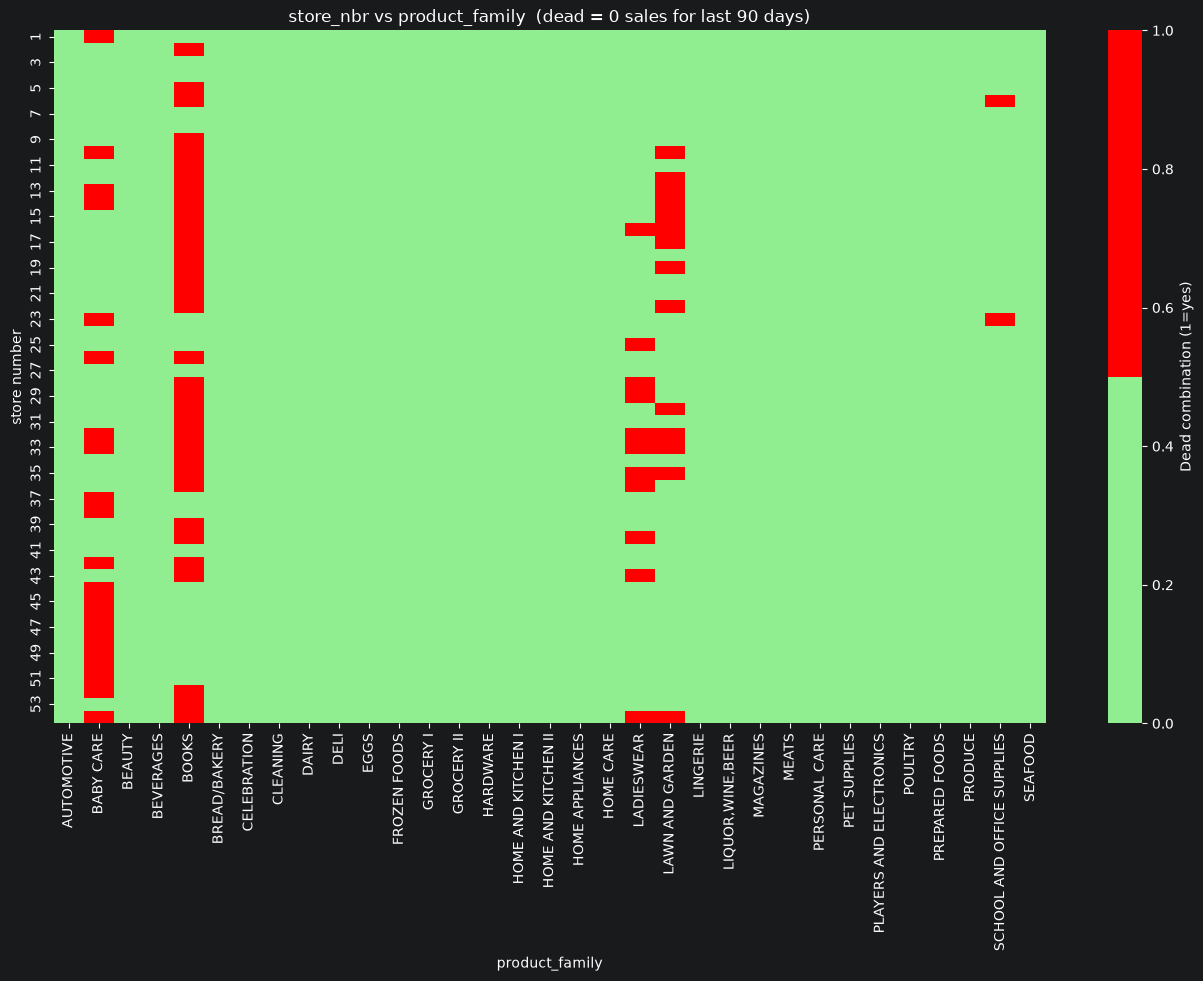

In [34]:
#create a empty matrix
#rows represents the store number
#columns represents the product families (encoded, converted to names for display)

dead_matrix = pd.DataFrame(
    0,
    index=sorted(test['store_nbr'].unique()),
    columns=sorted(test['family'].unique())
)

for (store,family) in true_dead_keys_enc:
  if store in dead_matrix.index and family in dead_matrix.columns:
    dead_matrix.loc[store,family] = 1

dead_matrix.columns = encoders['family'].inverse_transform(dead_matrix.columns)

#creat a heatmap
plt.figure(figsize=(16,9))
sns.heatmap(
    dead_matrix,
    cmap=['lightgreen', 'red'],
    cbar_kws={'label':'Dead combination (1=yes)'}
)
plt.title("store_nbr vs product_family  (dead = 0 sales for last 90 days)")
plt.xlabel('product_family')
plt.ylabel('store number')
plt.xticks(rotation=90)
plt.show()

**6.2 Lgbm feature importance**

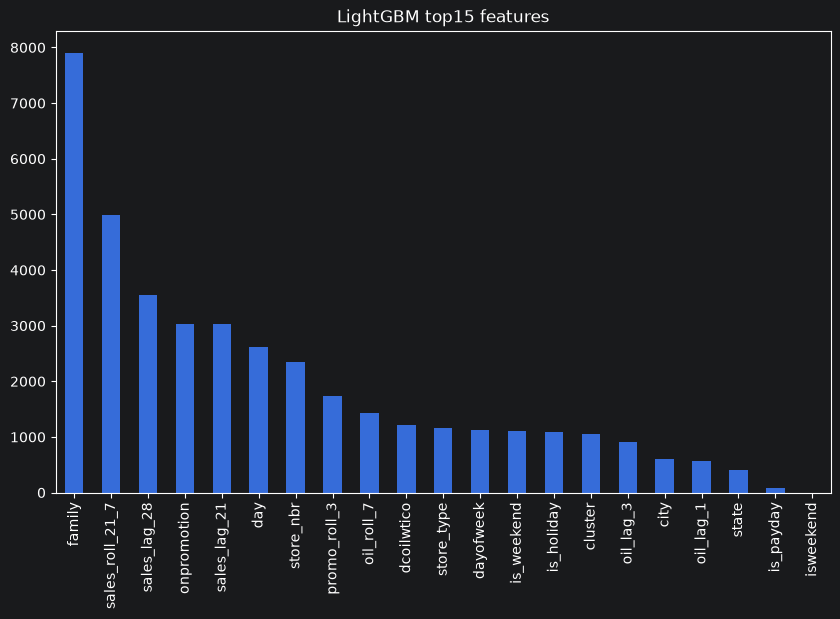

In [35]:
importance = m_lgb.feature_importances_
feat_imp = pd.Series(importance,index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.head(25).plot(kind='bar')
plt.title("LightGBM top15 features")
plt.show()

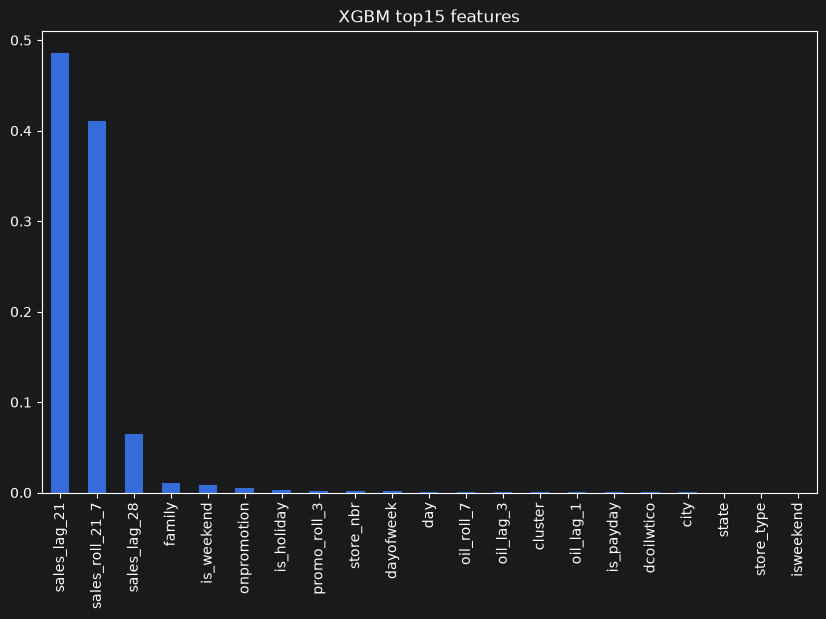

In [36]:
importence = m_xgb.feature_importances_
feat_imp = pd.Series(importence,index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.head(25).plot(kind='bar')
plt.title("XGBM top15 features")
plt.show()

**7 submission of file generation**

In [38]:
print("Applying the safe post processing rules")

# Rule: store-family combinations with 0 sales for 90 straight days are forecast as 0
dead_mask = pd.Series(
    [(s, f) in true_dead_keys_enc for s, f in zip(test['store_nbr'], test['family'])],
    index=test.index
)

print(f"Rows forced to 0 by the dead-product rule: {int(dead_mask.sum())}")

test.loc[dead_mask, 'sales'] = 0.0

submission = pd.DataFrame({
    "id": test['id'].astype(int),
    "sales": test['sales']
})

# Save locally
submission.to_csv("submission.csv", index=False)

print("submission file has been created successfully")

Applying the safe post processing rules
Rows forced to 0 by the dead-product rule: 1312
submission file has been created successfully


**Model Evaluation**

In [40]:
#check the evaluation metrics and convert to pickle file to build the ai model
#find the MAE,MSE,R2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

**ensemble predictions**

In [41]:
pred_val = (
    best_w[0]*p_lgb_val+
    best_w[1]*p_xgb_val
)
pred_val

#original-scale actuals (y_val is log1p) so every metric below compares like with like
y_val_original = np.expm1(y_val)

**MAE**

In [42]:

mae = mean_absolute_error(y_val_original,pred_val)
mae

85.16882985426577

**MSE**

In [43]:
mse = mean_squared_error(y_val_original,pred_val)
mse

85466.00351066142

**RMSE**

In [44]:
rmse = np.sqrt(mean_squared_error(y_val_original,pred_val))
rmse

np.float64(292.34569179425483)

**R2_Score**

In [45]:
r2 = r2_score(y_val_original,pred_val)
r2

0.9447980424414979

In [46]:
y_val_original = np.expm1(y_val)

In [47]:
y_val_original[:10]

217404       5.00000
217405       0.00000
217406       4.00000
217407    2627.00000
217408       0.00000
217409     373.70898
217410      11.00000
217411     867.00000
217412     668.00000
217413     133.58800
Name: sales, dtype: float64

In [48]:
r2 = r2_score(y_val_original,pred_val)
r2

0.9447980424414979

In [49]:
mae = mean_absolute_error(y_val_original,pred_val)
mae

85.16882985426577

In [50]:
rmse = np.sqrt(mean_squared_error(y_val_original,pred_val))
rmse

np.float64(292.34569179425483)

In [51]:
mse = mean_squared_error(y_val_original,pred_val)
mse

85466.00351066142

**Save the evaluation metrics**

In [52]:
metrics = {
    "MAE":float(mae),
    "RMSE":float(rmse),
    "RMSLE":float(rmsle(y_val_original, pred_val)),   # a number now (was the function object itself)
    "r2_score":float(r2)
}
print(metrics)

{'MAE': 85.16882985426577, 'RMSE': 292.34569179425483, 'RMSLE': 0.4156162560924279, 'r2_score': 0.9447980424414979}


**convert the metrics to pickle file**

In [53]:
import pickle
pickle.dump(metrics, open("models/metrics.pkl", "wb"))

**Save the model to pickle file**

In [54]:


with open("lightgbm_model.pkl","wb") as file:
  pickle.dump(m_lgb,file)
print("lightgbm model is saved successfully")

lightgbm model is saved successfully


In [55]:
#save xgboost model
with open("xgboost_model.pkl","wb") as file:
  pickle.dump(m_xgb,file)
print("xgboost model is saved successfully ")

xgboost model is saved successfully 


In [56]:
#save the best ensemble weights
best_w

[np.float64(0.25000000000000006), np.float64(0.75)]

In [57]:
with open("models/ensemble_weight.pkl", "wb") as file:
  pickle.dump(best_w,file)
print("ensemble_weights are saved successfully")

ensemble_weights are saved successfully


In [58]:
#save label encoding
encoders

{'family': LabelEncoder(),
 'city': LabelEncoder(),
 'state': LabelEncoder(),
 'store_type': LabelEncoder()}

In [59]:
with open("label_encoders.pkl","wb") as file:
  pickle.dump(encoders,file)
print("label_encoders are saved successfully")

label_encoders are saved successfully


In [60]:
#save features in pkl format
with open("models/features_columns.pkl", "wb") as file:
  pickle.dump(features,file)
print(" features_columns are saved successfully")

 features_columns are saved successfully


In [61]:
print(features)

['store_nbr', 'family', 'onpromotion', 'is_weekend', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'oil_roll_7', 'oil_lag_1', 'oil_lag_3', 'is_holiday', 'day', 'dayofweek', 'isweekend', 'is_payday', 'sales_lag_21', 'sales_lag_28', 'sales_roll_21_7', 'promo_roll_3']


In [62]:
X_all[features]

,store_nbr,family,onpromotion,is_weekend,city,state,store_type,cluster,dcoilwtico,oil_roll_7,...,oil_lag_3,is_holiday,day,dayofweek,isweekend,is_payday,sales_lag_21,sales_lag_28,sales_roll_21_7,promo_roll_3
49896,1,0,0,1,18,12,3,13,49.15,49.129524,...,49.220000,0,29,5,1,0,8.000,9.000,7.142857,0.000000
49897,1,1,0,1,18,12,3,13,49.15,49.129524,...,49.220000,0,29,5,1,0,0.000,0.000,0.000000,0.000000
49898,1,2,0,1,18,12,3,13,49.15,49.129524,...,49.220000,0,29,5,1,0,2.000,1.000,2.428571,0.000000
49899,1,3,33,1,18,12,3,13,49.15,49.129524,...,49.220000,0,29,5,1,0,2729.000,3229.000,2237.571429,31.000000
49900,1,4,0,1,18,12,3,13,49.15,49.129524,...,49.220000,0,29,5,1,0,0.000,0.000,0.571429,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244129,9,28,0,0,18,12,1,6,47.57,48.357143,...,48.403333,0,15,1,0,1,320.009,320.401,392.798569,0.000000
244130,9,29,1,0,18,12,1,6,47.57,48.357143,...,48.403333,0,15,1,0,1,51.879,118.927,86.165143,0.666667
244131,9,30,148,0,18,12,1,6,47.57,48.357143,...,48.403333,0,15,1,0,1,2100.046,2178.149,1565.428143,54.000000
244132,9,31,8,0,18,12,1,6,47.57,48.357143,...,48.403333,0,15,1,0,1,5.000,0.000,1.857143,9.000000


In [63]:
X_all["family"]

49896      0
49897      1
49898      2
49899      3
49900      4
          ..
244129    28
244130    29
244131    30
244132    31
244133    32
Name: family, Length: 194238, dtype: int64

In [64]:
X_all["onpromotion"]

49896       0
49897       0
49898       0
49899      33
49900       0
         ... 
244129      0
244130      1
244131    148
244132      8
244133      0
Name: onpromotion, Length: 194238, dtype: int64

In [65]:
X_all['store_type']

49896     3
49897     3
49898     3
49899     3
49900     3
         ..
244129    1
244130    1
244131    1
244132    1
244133    1
Name: store_type, Length: 194238, dtype: int64

In [66]:
X_all["cluster"]

49896     13
49897     13
49898     13
49899     13
49900     13
          ..
244129     6
244130     6
244131     6
244132     6
244133     6
Name: cluster, Length: 194238, dtype: int64

In [67]:
X_all["is_weekend"]

49896     1
49897     1
49898     1
49899     1
49900     1
         ..
244129    0
244130    0
244131    0
244132    0
244133    0
Name: is_weekend, Length: 194238, dtype: int64

In [68]:
X_all['dcoilwtico']

49896     49.15
49897     49.15
49898     49.15
49899     49.15
49900     49.15
          ...  
244129    47.57
244130    47.57
244131    47.57
244132    47.57
244133    47.57
Name: dcoilwtico, Length: 194238, dtype: float64

In [69]:
import os
os.makedirs("models", exist_ok=True)

m_xgb.get_booster().save_model("models/xgboost_model.json")
print(" XGBoost saved")

m_lgb.booster_.save_model("models/lightgbm_model.txt")
print(" LightGBM saved")

for f in ["models/xgboost_model.json", "models/lightgbm_model.txt"]:
    size = os.path.getsize(f)
    print(f"{f}: {size} bytes", " OK" if size > 0 else " EMPTY - something went wrong")

 XGBoost saved
 LightGBM saved
models/xgboost_model.json: 13684715 bytes  OK
models/lightgbm_model.txt: 3851547 bytes  OK


In [71]:
import os

models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

m_xgb.get_booster().save_model(f"{models_dir}/xgboost_model.json")
m_lgb.booster_.save_model(f"{models_dir}/lightgbm_model.txt")

print("Models saved successfully to local models folder")

Models saved successfully to local models folder


In [75]:
# Verification cell
sub_check = pd.read_csv("submission.csv")

print("Columns:", sub_check.columns.tolist())
sub_check.head(7)

Columns: ['id', 'sales']


,id,sales
0,3000888,4.460918
1,3000889,0.000000
2,3000890,5.001966
3,3000891,2443.263515
4,3000892,0.226791
5,3000893,410.151858
6,3000894,14.712051


In [76]:
print("LightGBM weight:", best_w[0] * 100, "%")
print("XGBoost weight:", best_w[1] * 100, "%")
print("Total:", (best_w[0] + best_w[1]) * 100, "%")

LightGBM weight: 25.000000000000007 %
XGBoost weight: 75.0 %
Total: 100.0 %
